# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

GLMs are helpful in analysis because they let us keep the explainability and interpretability of linear models while also allowing us to restrict our results. Linear models output results that range between $-\infty$ and $\infty$, but general linear models output results that are between $0$ and $1$ that can be thought of as probabilities. They add on activation functions to linear models that allow us to represent non-linear relationships.

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

Binary and categorical cross entropy are effective because they force you to match $y$ and $b$ to either both be $0$ or both be $1$. They directly compare predictions to the actual labels and reward confident correct answers.

3. True or false, and explain: Logistic regression is a linear model.

False. Logistic regression adds a non-linear activation function on top of a linear model. Thus, the whole logistic regression is non-linear.

4. True or false, and explain: Logistic regression cannot be used for classification.

False. Logistic regression can be used for classification because you can just report the most probable outcome as the class. The regression gives probabilites and then you can just look at those to determine the most likely classification.

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

No it does not. Because of the activation function, the coefficients in logistic regression models cannot be interepreted in the same way that coefficients in linear models can be.

6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

False. Feature engineering is still important.

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

False. Logistic regression can be helpful if variables have a non-linear relationship, but if the relationship is linear, a linear model would be better. When the outcome is categorical (especially binary), logistic regression is better; but when the outcome is numeric, linear regression is better.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

In [2]:
college = pd.read_csv('../data/data.csv', sep=';')
college = college.loc[:, ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (approved)', 'Target']]
college.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target
0,0,1,0,20,0,Dropout
1,0,0,0,19,6,Graduate
2,0,0,0,19,0,Dropout
3,0,1,0,20,6,Graduate
4,0,1,0,45,5,Graduate


In [3]:
college.isna().sum()

Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64

There are no missing values in this dataset.

In [4]:
college['Binary target'] = [1 if val == 'Dropout' else 0 for val in college['Target']]
college.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,Binary target
0,0,1,0,20,0,Dropout,1
1,0,0,0,19,6,Graduate,0
2,0,0,0,19,0,Dropout,1
3,0,1,0,20,6,Graduate,0
4,0,1,0,45,5,Graduate,0


2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?


In [5]:
x_college = college.loc[:, ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']]
y = college['Binary target']

In [6]:
model_college = LogisticRegression(penalty=None)
model_college.fit(x_college, y)

/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [7]:
coefs_college = pd.DataFrame({'variable': model_college.feature_names_in_, 'coef': model_college.coef_[0]})
coefs_college

,variable,coef
0,Debtor,0.527137
1,Tuition fees up to date,-2.605617
2,Scholarship holder,-1.242299
3,Age at enrollment,0.049841


Being a `Debtor` and having a higher `Age at enrollment` seem to predict a higher dropout probability, while having `Tuition fees up to date` and being a `Scholarship holder` seem to predict a lower dropout probability. Yes, being up to date on tuition seems to reduce dropout risk.

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

In [8]:
y_pred = model_college.predict_proba(x_college)
y_pred = [row[1] for row in y_pred]

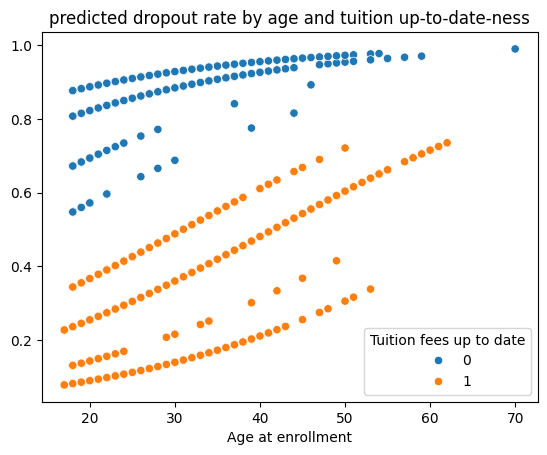

In [9]:
sns.scatterplot(x=college['Age at enrollment'], y=y_pred, hue=college['Tuition fees up to date'])
plt.title('predicted dropout rate by age and tuition up-to-date-ness')
plt.show()

In [10]:
x_and_y_pred = pd.concat([college['Age at enrollment'], college['Tuition fees up to date'], pd.DataFrame(y_pred)], axis=1)
x_and_y_pred.columns = ['Age at enrollment', 'Up to date', 'Prediction']

In [11]:
age_groups = [(0, 10), (11, 20), (21, 30), (31, 40), (41, 50), (51, 60), (61, 70), (71, 80)]

age_groups_list = []
probs_up_to_date_list = []
probs_not_up_to_date_list = []

for younger_age, older_age in age_groups:

    y_subset = x_and_y_pred[x_and_y_pred['Age at enrollment'] >= younger_age]
    y_subset = y_subset[y_subset['Age at enrollment'] <= older_age]

    y_subset_up_to_date = y_subset[y_subset['Up to date'] == 1]
    y_subset_not_up_to_date = y_subset[y_subset['Up to date'] == 0]

    age_groups_list.append(str(younger_age) + ' to ' + str(older_age))
    probs_up_to_date_list.append(y_subset_up_to_date['Prediction'].mean())
    probs_not_up_to_date_list.append(y_subset_not_up_to_date['Prediction'].mean())

tuition_effect_by_age = pd.DataFrame({'age group': age_groups_list, 'avg pred prob if up to date': probs_up_to_date_list, 'avg pred prob if not up to date': probs_not_up_to_date_list, 'difference': np.array(probs_up_to_date_list) - np.array(probs_not_up_to_date_list)})
tuition_effect_by_age.sort_values('difference')

,age group,avg pred prob if up to date,avg pred prob if not up to date,difference
1,11 to 20,0.195477,0.806907,-0.611430
2,21 to 30,0.269553,0.869010,-0.599457
3,31 to 40,0.394204,0.917969,-0.523766
4,41 to 50,0.518671,0.949156,-0.430485
5,51 to 60,0.634777,0.967407,-0.332630
6,61 to 70,0.730027,0.989557,-0.259530
0,0 to 10,NaN,NaN,NaN
7,71 to 80,NaN,NaN,NaN


For ages 11 to 20, being up to date on tuition has the biggest impact on predicted dropout probability. The mean prediction goes down from about $80.7$% to about $19.5$%. 

In [12]:
up_to_date = x_and_y_pred[x_and_y_pred['Up to date'] == 1]['Prediction'].mean()
not_up_to_date = x_and_y_pred[x_and_y_pred['Up to date'] == 0]['Prediction'].mean()


avg_difference = up_to_date - not_up_to_date

print('on average, being up to date on tuition changes the predicted dropout probability by', avg_difference * 100, '%')

on average, being up to date on tuition changes the predicted dropout probability by -61.81006153586197 %


4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

In [14]:
y_pred_class = model_college.predict(x_college)

confusion_matrix = pd.crosstab(y_pred_class, college['Binary target'])
confusion_matrix

Binary target,0,1
row_0,,
0,2841,891
1,162,530


In [15]:
print('the accuracy is', np.trace(confusion_matrix) / len(y_pred_class))

the accuracy is 0.7619801084990958


5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

6. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

7. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 